### QQP with LMU


In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from qqp_task import QQPTask
from src.train_utils.trainer import Trainer

### Configuration

We define hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [3]:
from src.utils.block_factory import make_lmu_block_cfg_ctor

In [5]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "qqp" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 256,
    "data_loader_kwargs": {
        "num_workers": 0,
        "max_len": 64,
        "max_vocab": 50_000,
        "min_freq": 2,
        "lowercase": True,
        "val_ratio": 0.1,
        "test_ratio": 0.1,
        "pin_memory": False,
        "persistent_workers": False,
        "seed": 42,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/qqp_lmu_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 1,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",

    # QQP specific
    "max_len": 64,
}

args["block_cfg_ctor"] = make_lmu_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

Using MPS


### Training

With the configuration set up, we instantiate the `QQPTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [6]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = QQPTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

### Visualization

Load the best checkpoint and visualize the training history.

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 35
Val metrics: {'loss': 0.47544479409254153, 'time_s': 9.953086165999594, 'acc': 0.7825151477886599}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

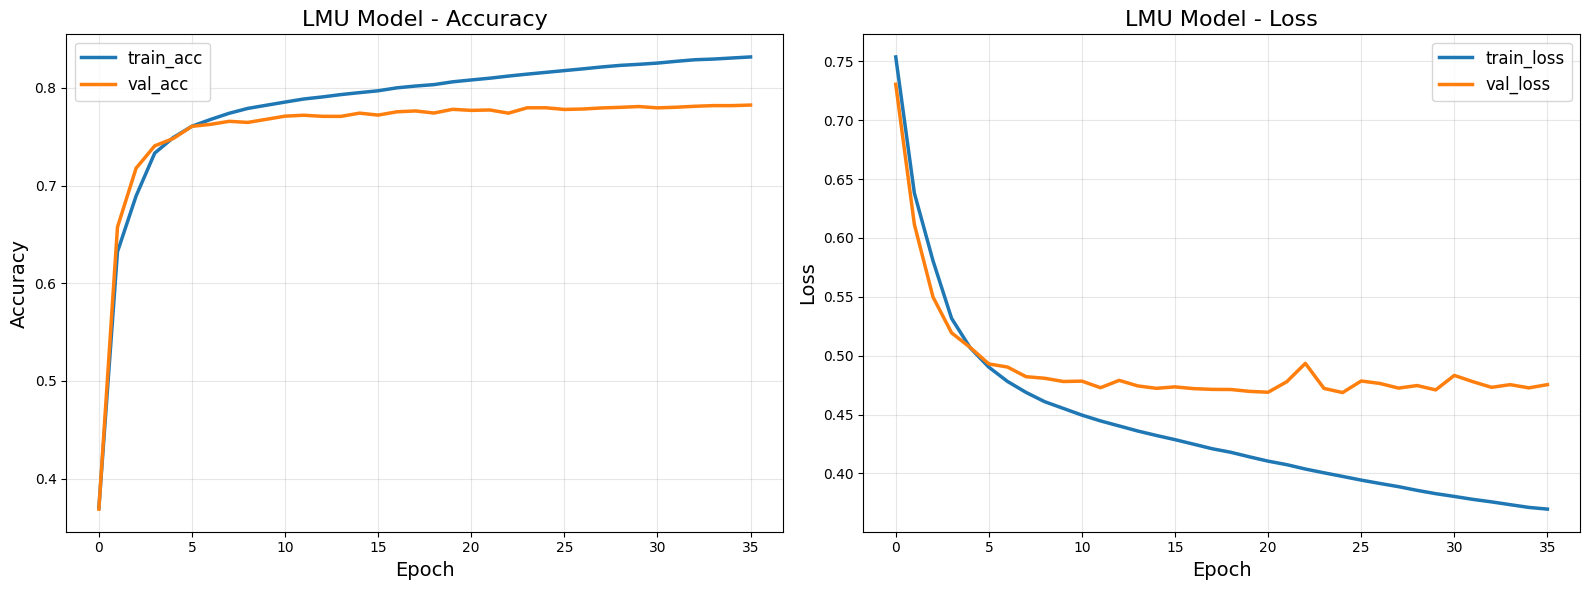

In [6]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=QQPTask(),
)

history = trainer.history

plot_history(history, model_name="LMU")

### Evaluation

After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

Loaded checkpoint from epoch 35
Val metrics: {'loss': 0.47544479409254153, 'time_s': 9.953086165999594, 'acc': 0.7825151477886599}
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_lmu_task_2/test_results.json

   Test Accuracy: 0.7873 (78.73%)
   Test Loss: 0.4713

TEST SET RESULTS
Overall accuracy: 0.7873
Num classes: 2

1. ROC Curve...


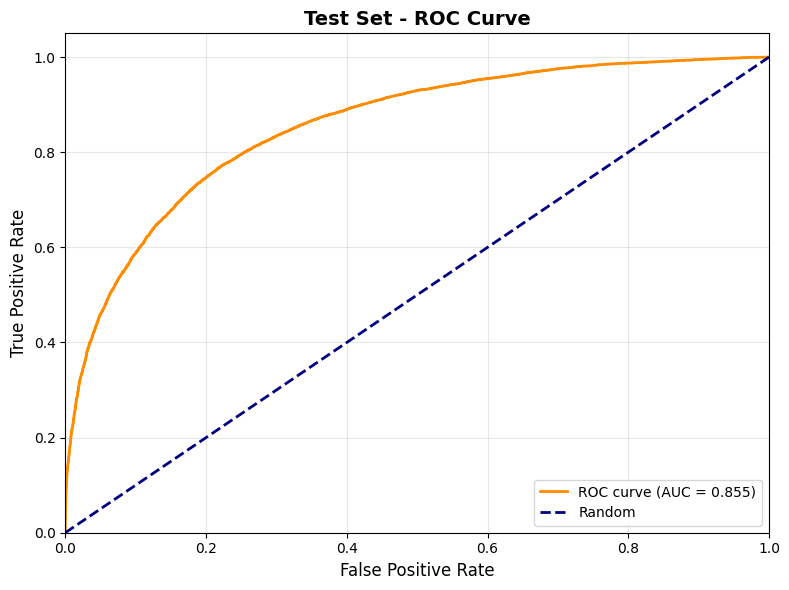

2. Precision-Recall Curve...


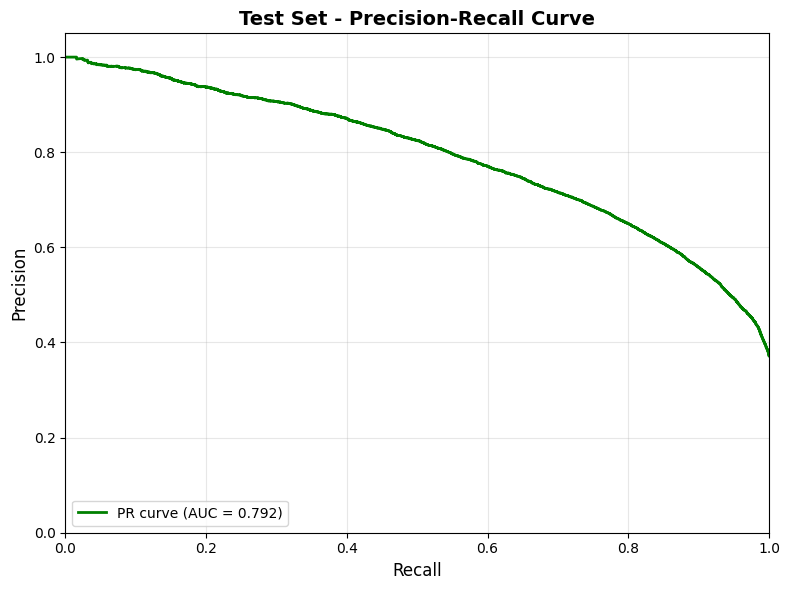

3. Confusion Matrix...


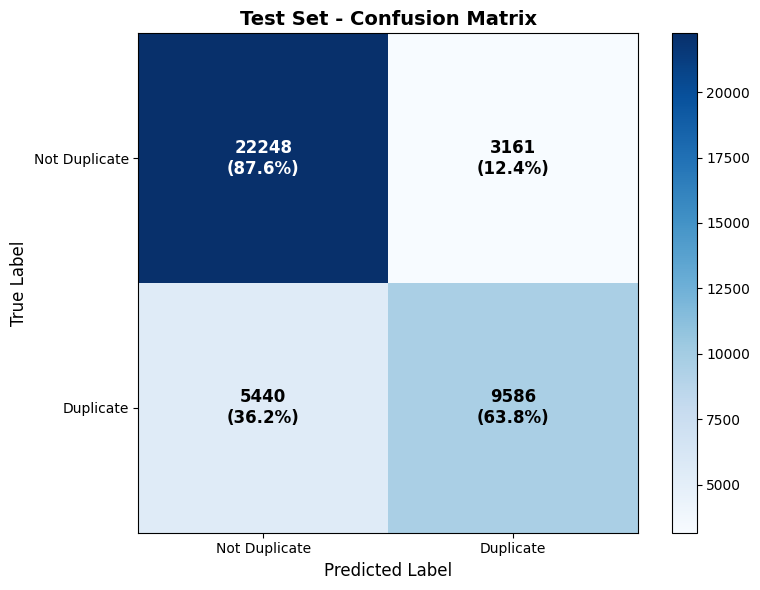

4. Threshold Analysis...


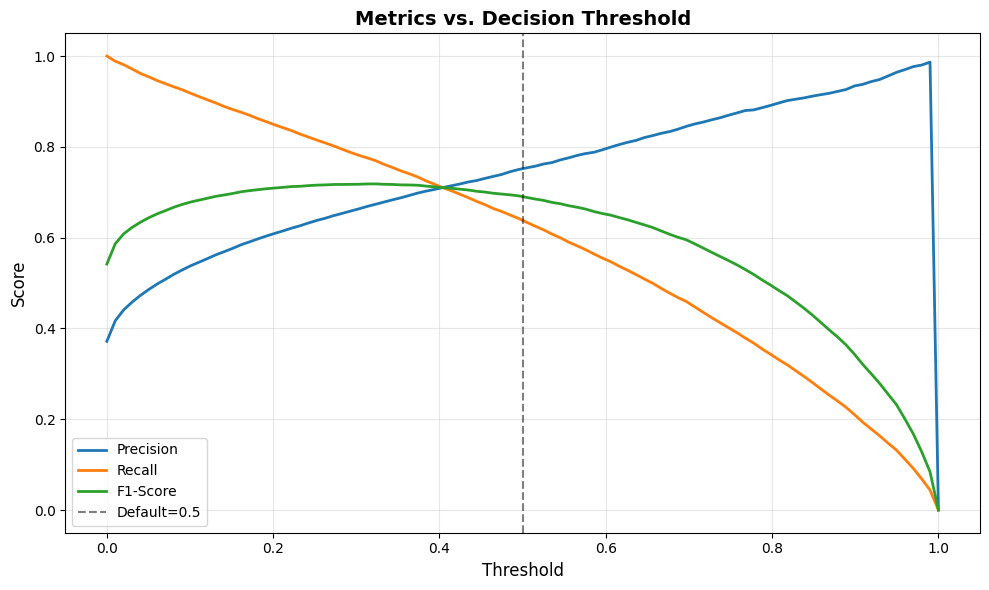

5. Metrics Summary...


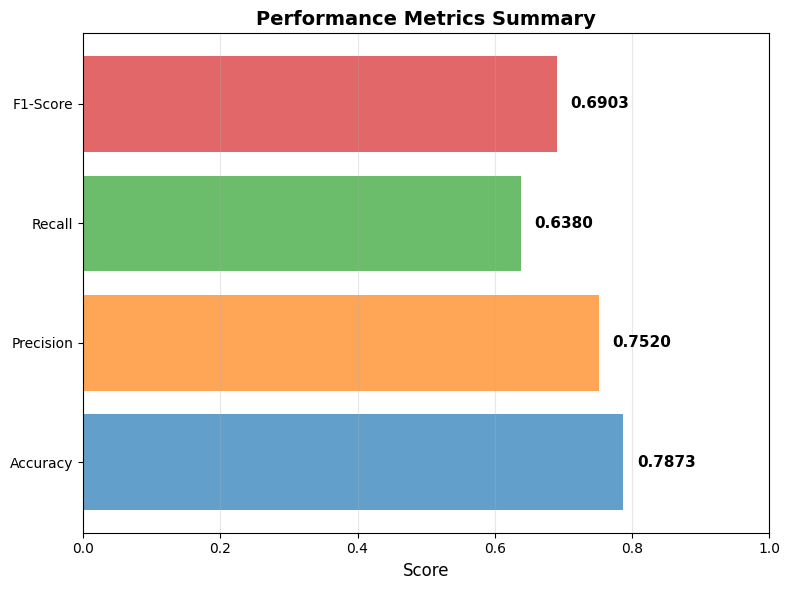

6. Class Distribution...


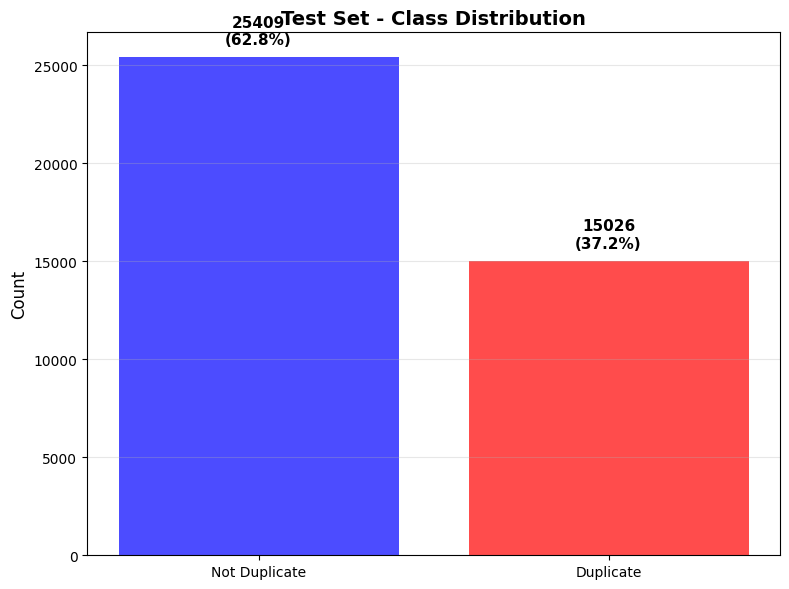


All visualizations generated!


In [7]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=QQPTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=2,
    use_test_set=True,
)

### Training with Different Dataset Fractions

This cell demonstrates training with different fractions of the training data
to see how model performance scales with dataset size.


Training with fraction: 0.1
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 10.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 32347
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

saved best model to ./runs/qqp_lmu_task_frac_10/best.pt
new best acc 0.3676
Epoch 000/50 | train 0.7328/0.3690 | val 0.7310/0.3676 | t 22.6s/9.7s | lr 1.00e-06


saved best model to ./runs/qqp_lmu_task_frac_10/best.pt
new best acc 0.6323
Epoch 001/50 | train 0.6696/0.6147 | val 0.6626/0.6323 | t 20.9s/9.5s | lr 2.01e-04


Epoch 002/50 | train 0.6586/0.6309 | val 0.6516/0.6324 | t 20.5s/9.5s | lr 4.01e-04


...

Epoch 021/50 | train 0.4072/0.8122 | val 0.5507/0.7379 | t 19.6s/9.4s | lr 7.19e-04


Epoch 022/50 | train 0.4016/0.8153 | val 0.5543/0.7383 | t 19.6s/9.4s | lr 6.87e-04


Epoch 023/50 | train 0.3962/0.8190 | val 0.5550/0.7316 | t 19.8s/9.4s | lr 6.55e-04


Epoch 024/50 | train 0.3903/0.8214 | val 0.5592/0.7363 | t 20.5s/9.5s | lr 6.21e-04


Early stopping (patience=5, best=0.7400).
Training history saved to ./runs/qqp_lmu_task_frac_10/history.json

Training complete for fraction 0.1! Best validation acc: 0.7400
Best model saved to: ./runs/qqp_lmu_task_frac_10/best.pt


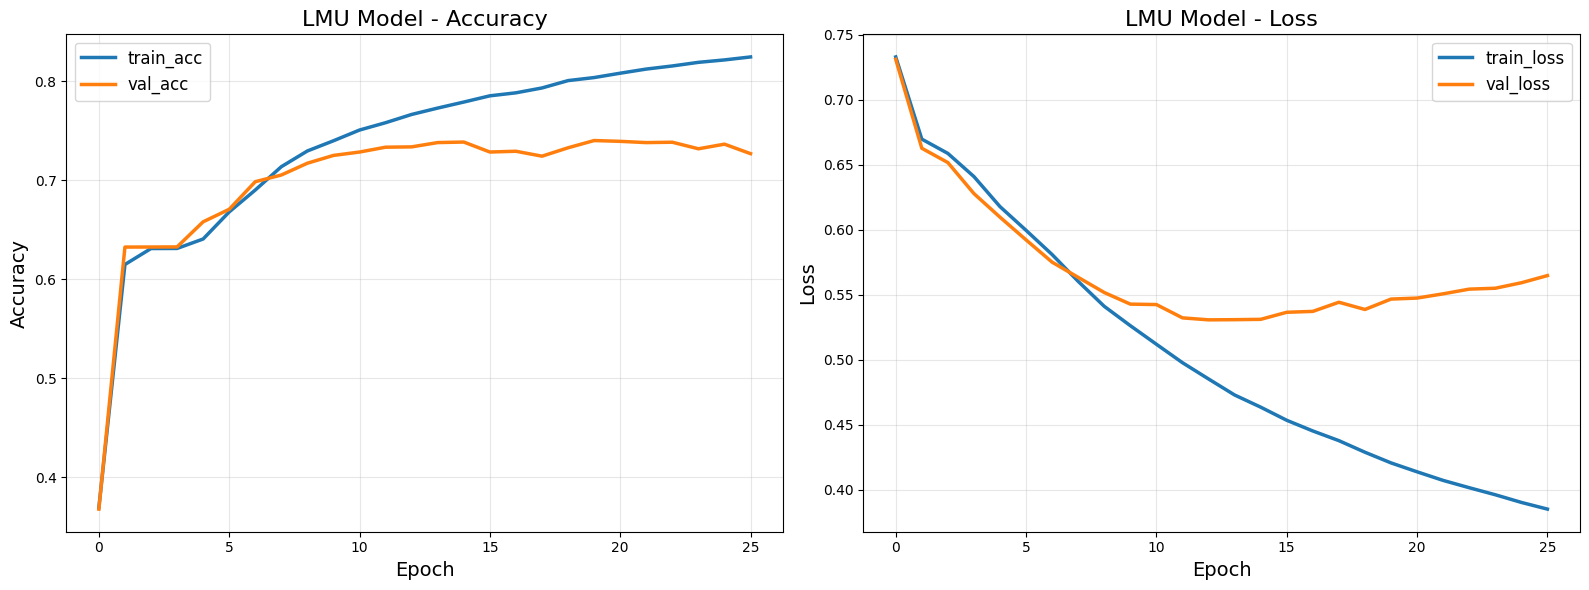

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 10.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 32347
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 19
Val metrics: {'loss': 0.5466324543302871, 'time_s': 9.393763499999977, 'acc': 0.7399777420551502}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_lmu_task_frac_10/test_results.json

   Test Accuracy: 0.7402 (74.02%)
   Test Loss: 0.5466

TEST SET RESULTS
Overall accuracy: 0.7402
Num classes: 2

1. ROC Curve...


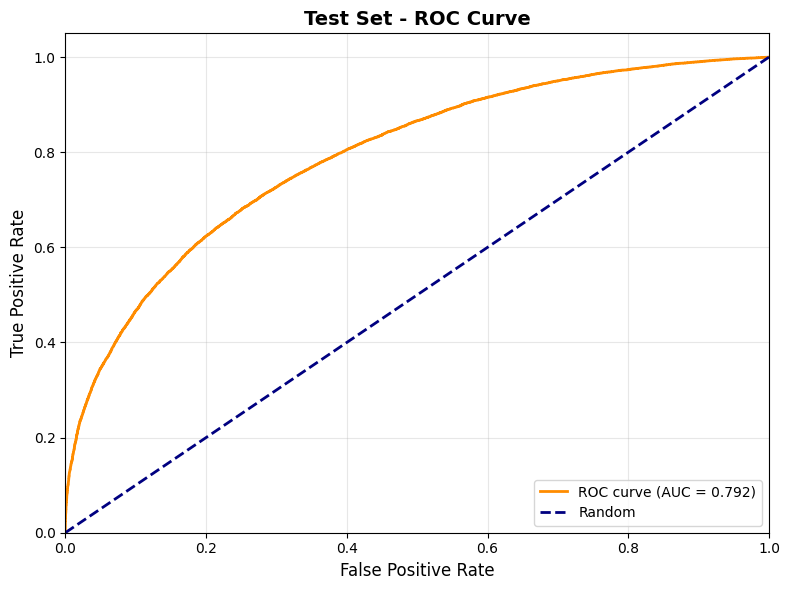

2. Precision-Recall Curve...


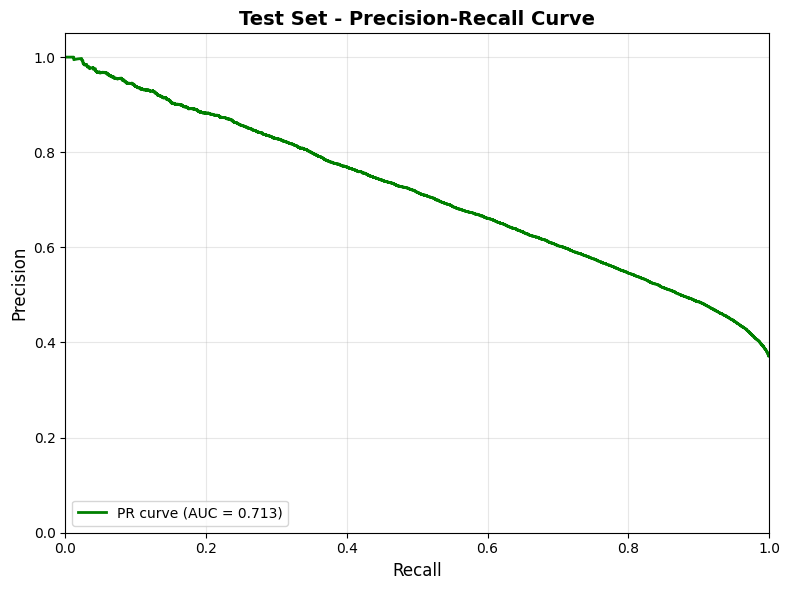

3. Confusion Matrix...


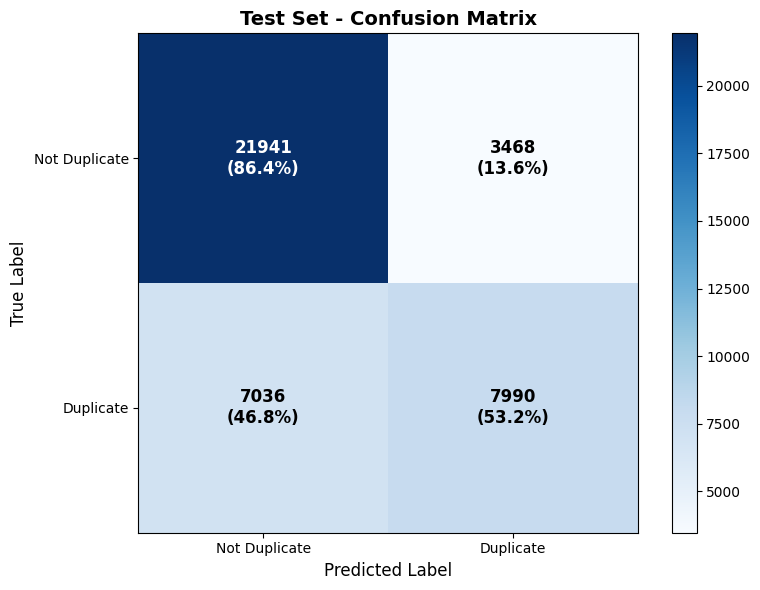

4. Threshold Analysis...


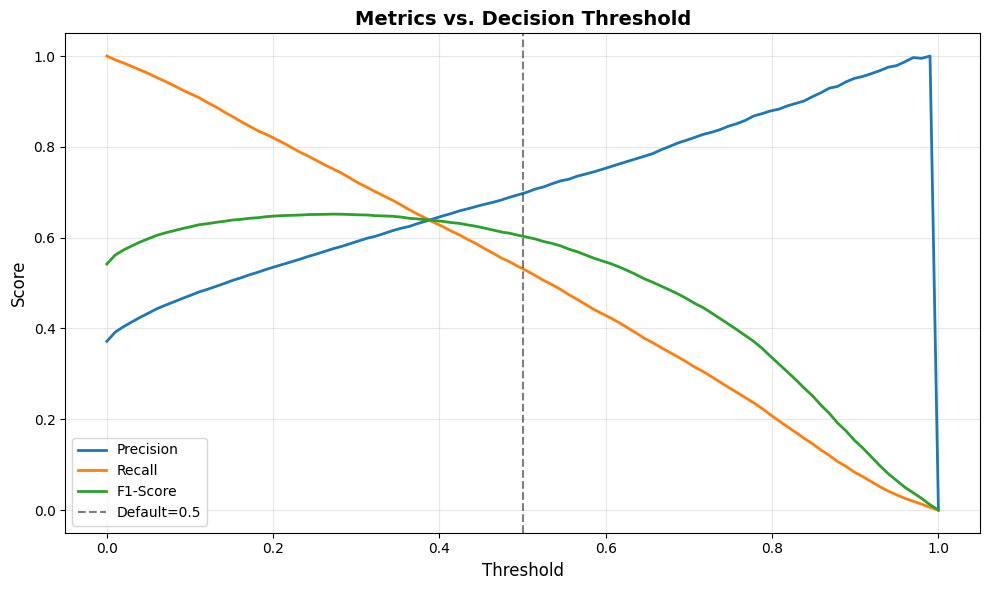

5. Metrics Summary...


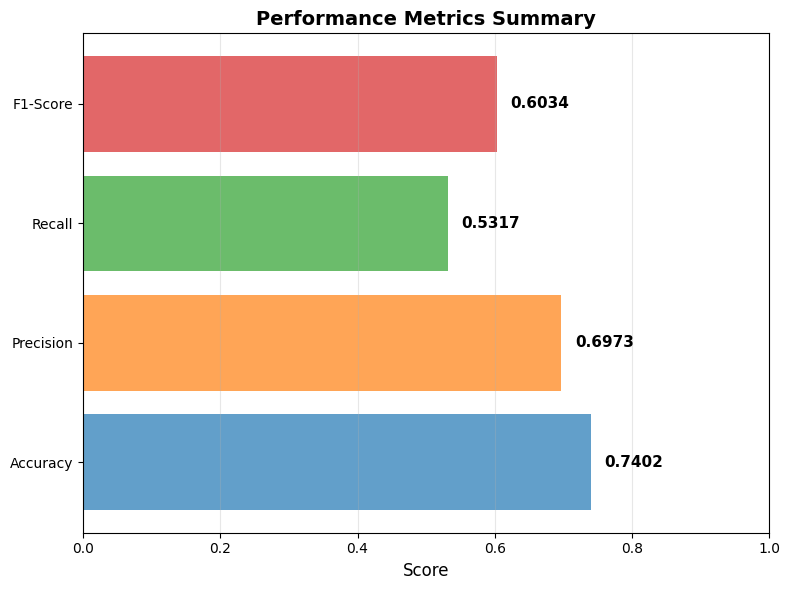

6. Class Distribution...


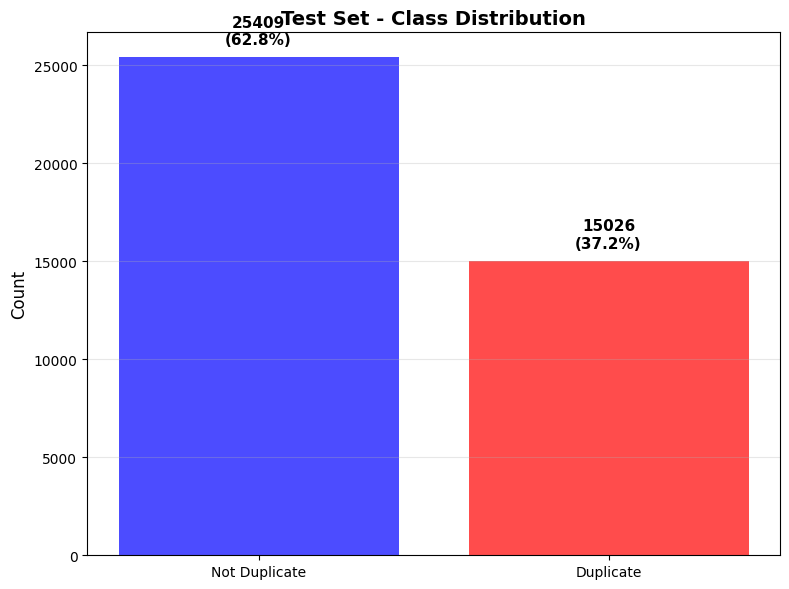


All visualizations generated!

Training with fraction: 0.25
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 25.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 80870
   Reduced val size: 40435
   Test size: 40435 (unchanged)


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

Using embedding layer with vocab_size=49367


saved best model to ./runs/qqp_lmu_task_frac_25/best.pt
new best acc 0.6323
Epoch 000/50 | train 0.6743/0.6307 | val 0.6719/0.6323 | t 49.7s/9.3s | lr 1.00e-06


Epoch 001/50 | train 0.6576/0.6310 | val 0.6517/0.6324 | t 48.8s/9.3s | lr 2.01e-04


...

Epoch 016/50 | train 0.4117/0.8084 | val 0.5183/0.7531 | t 51.4s/9.8s | lr 8.60e-04


Epoch 017/50 | train 0.4065/0.8113 | val 0.5234/0.7485 | t 51.5s/9.8s | lr 8.35e-04


Epoch 018/50 | train 0.4018/0.8145 | val 0.5261/0.7457 | t 51.8s/9.8s | lr 8.08e-04


Epoch 019/50 | train 0.3960/0.8176 | val 0.5258/0.7526 | t 51.9s/9.9s | lr 7.80e-04


Early stopping (patience=5, best=0.7529).
Training history saved to ./runs/qqp_lmu_task_frac_25/history.json

Training complete for fraction 0.25! Best validation acc: 0.7529
Best model saved to: ./runs/qqp_lmu_task_frac_25/best.pt


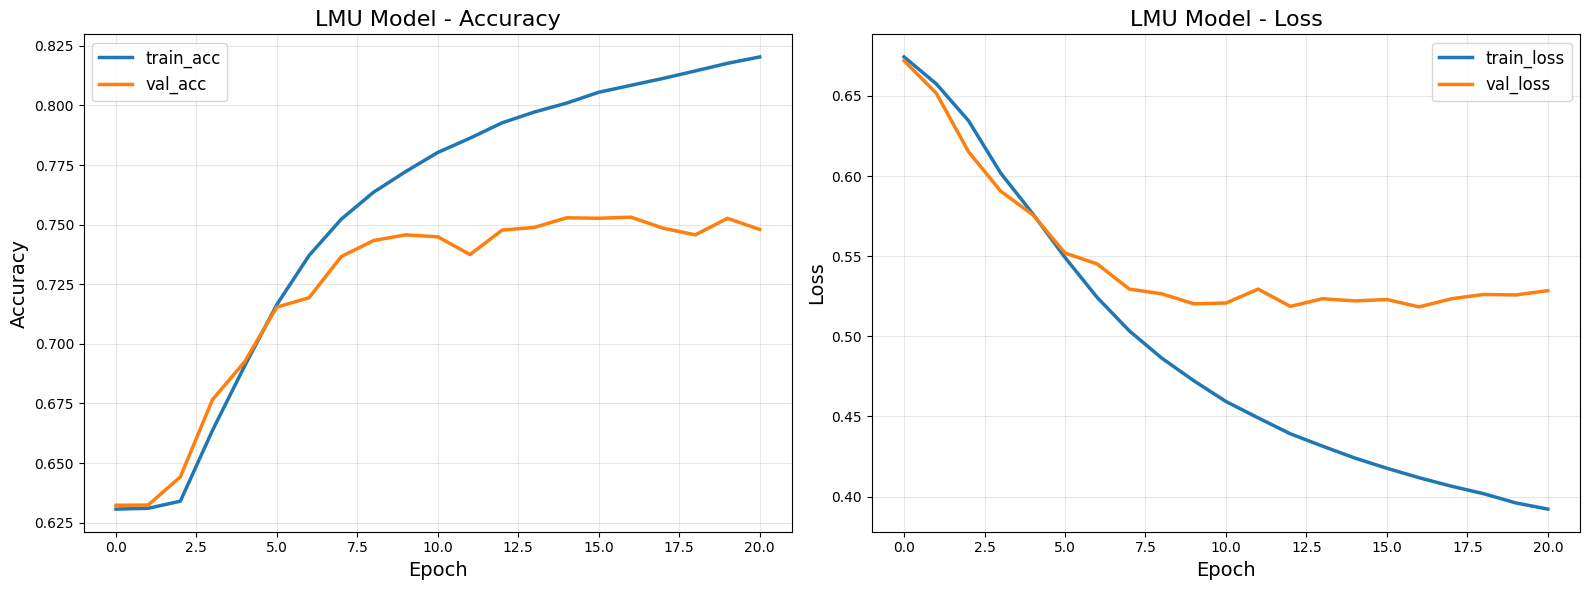

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 25.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 80870
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 14
Val metrics: {'loss': 0.5220655426189544, 'time_s': 9.852019833999975, 'acc': 0.7528626190181773}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_lmu_task_frac_25/test_results.json

   Test Accuracy: 0.7520 (75.20%)
   Test Loss: 0.5225

TEST SET RESULTS
Overall accuracy: 0.7520
Num classes: 2

1. ROC Curve...


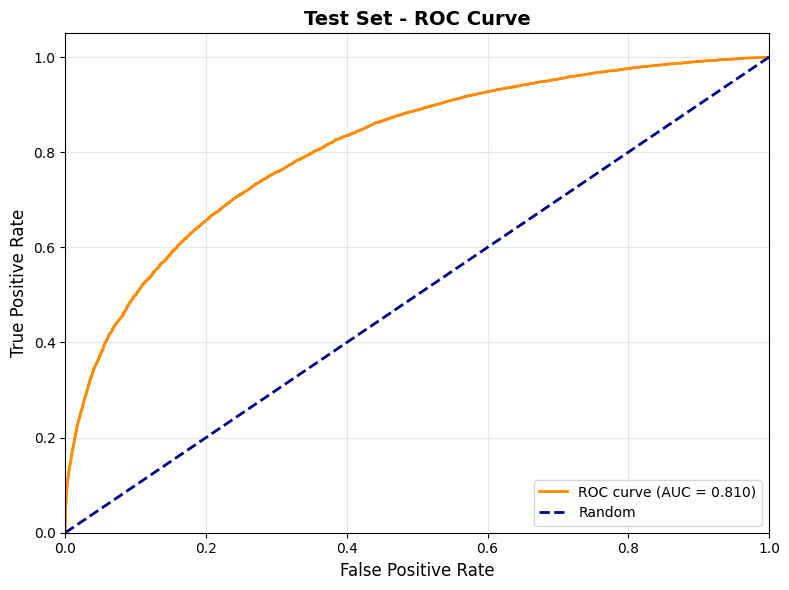

2. Precision-Recall Curve...


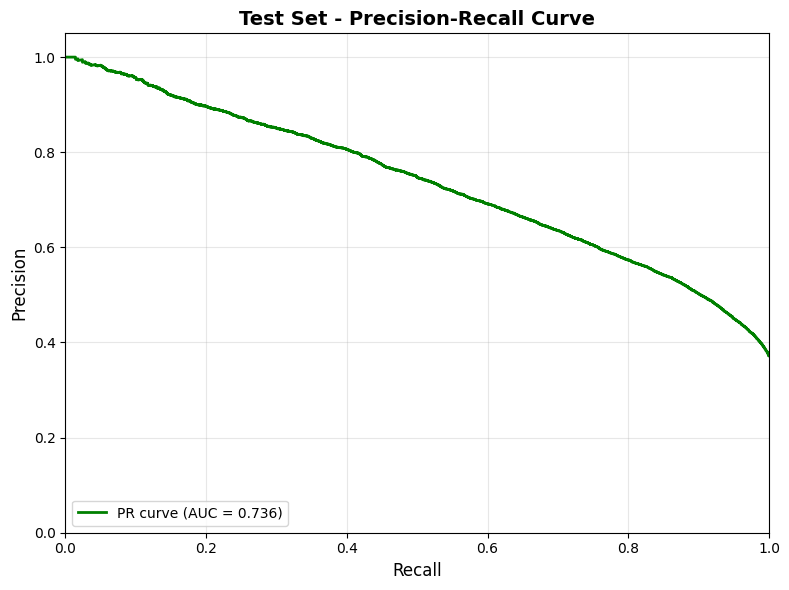

3. Confusion Matrix...


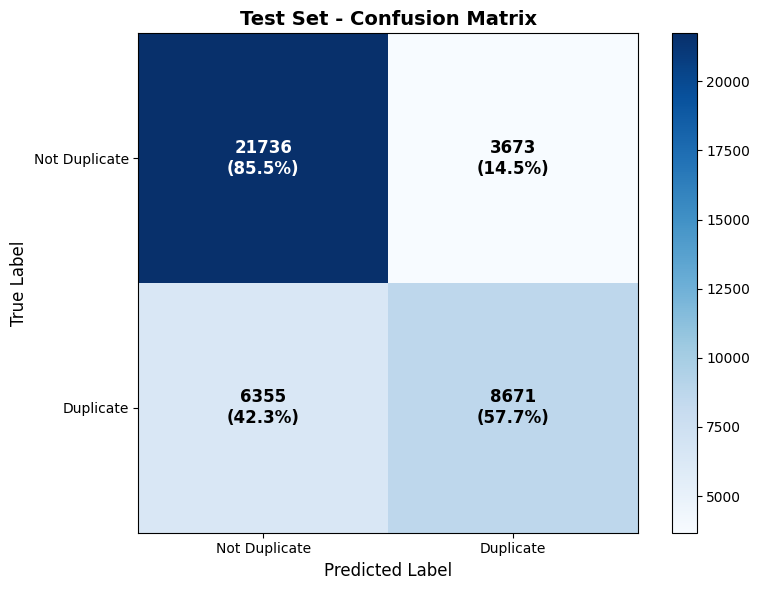

4. Threshold Analysis...


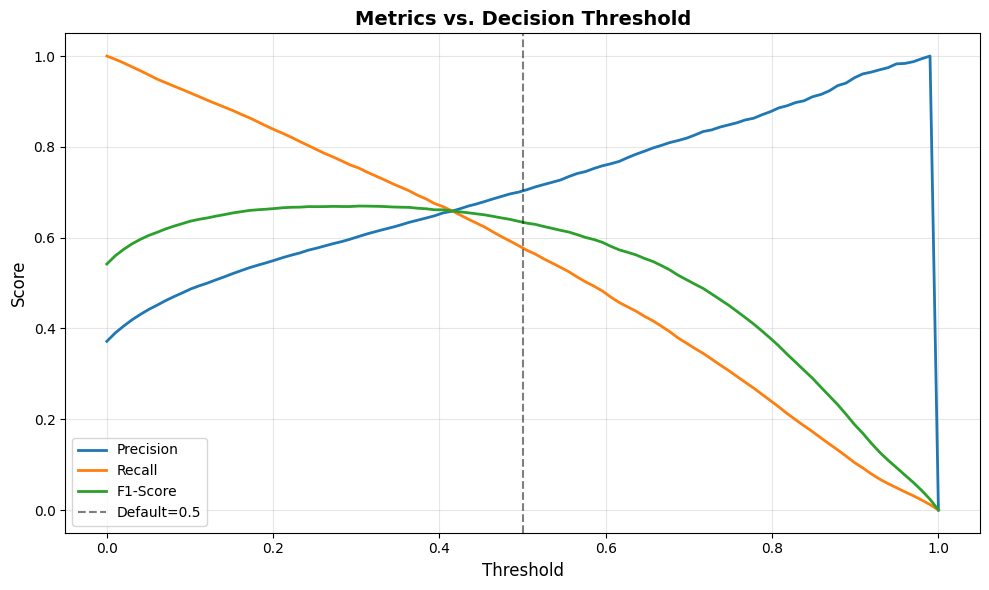

5. Metrics Summary...


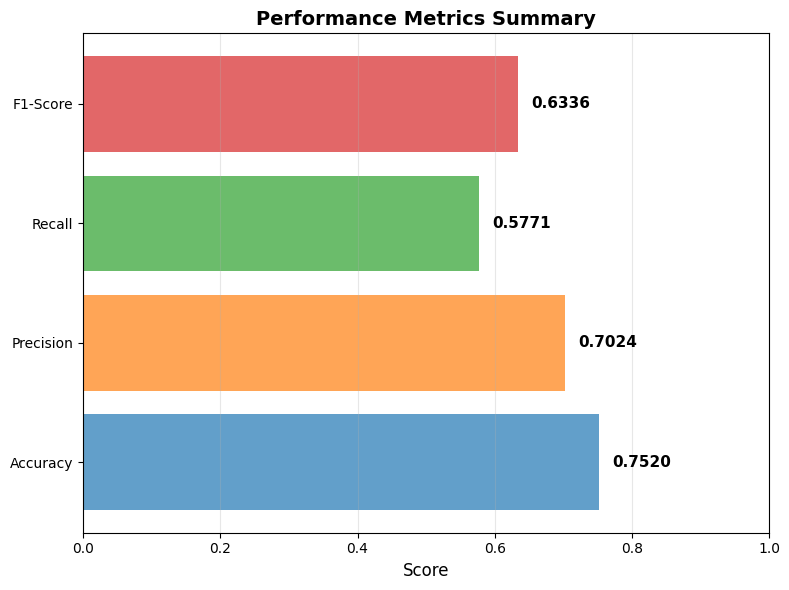

6. Class Distribution...


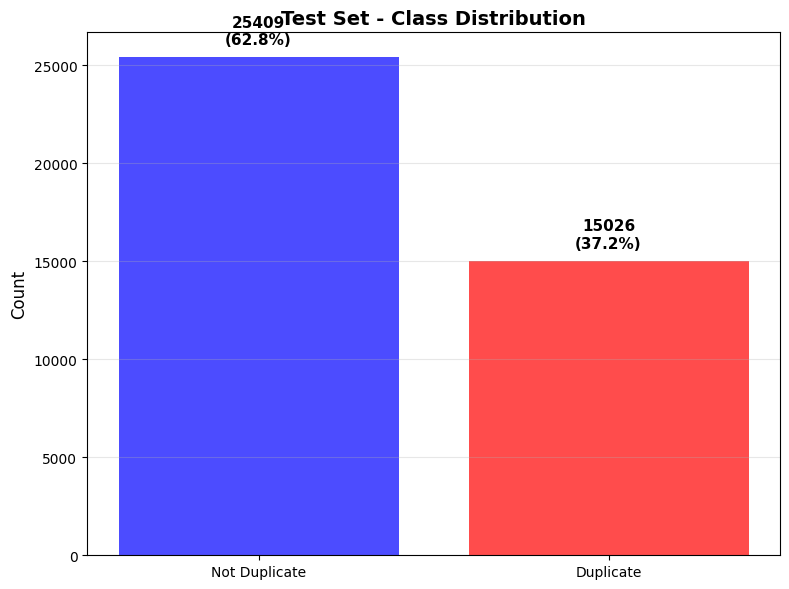


All visualizations generated!

Training with fraction: 0.5
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 50.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 161740
   Reduced val size: 40435
   Test size: 40435 (unchanged)


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

Using embedding layer with vocab_size=49367


saved best model to ./runs/qqp_lmu_task_frac_50/best.pt
new best acc 0.6323
Epoch 000/50 | train 0.6655/0.6308 | val 0.6635/0.6323 | t 103.7s/10.0s | lr 1.00e-06


Epoch 001/50 | train 0.6507/0.6308 | val 0.6317/0.6324 | t 107.9s/10.1s | lr 2.01e-04


...

Epoch 023/50 | train 0.3952/0.8181 | val 0.4947/0.7679 | t 109.4s/10.2s | lr 6.55e-04


Epoch 024/50 | train 0.3926/0.8200 | val 0.4931/0.7640 | t 109.7s/10.2s | lr 6.21e-04


Epoch 025/50 | train 0.3904/0.8209 | val 0.4981/0.7681 | t 111.4s/10.1s | lr 5.87e-04


Epoch 026/50 | train 0.3874/0.8225 | val 0.4870/0.7699 | t 112.3s/10.2s | lr 5.52e-04


Early stopping (patience=5, best=0.7690).
Training history saved to ./runs/qqp_lmu_task_frac_50/history.json

Training complete for fraction 0.5! Best validation acc: 0.7690
Best model saved to: ./runs/qqp_lmu_task_frac_50/best.pt


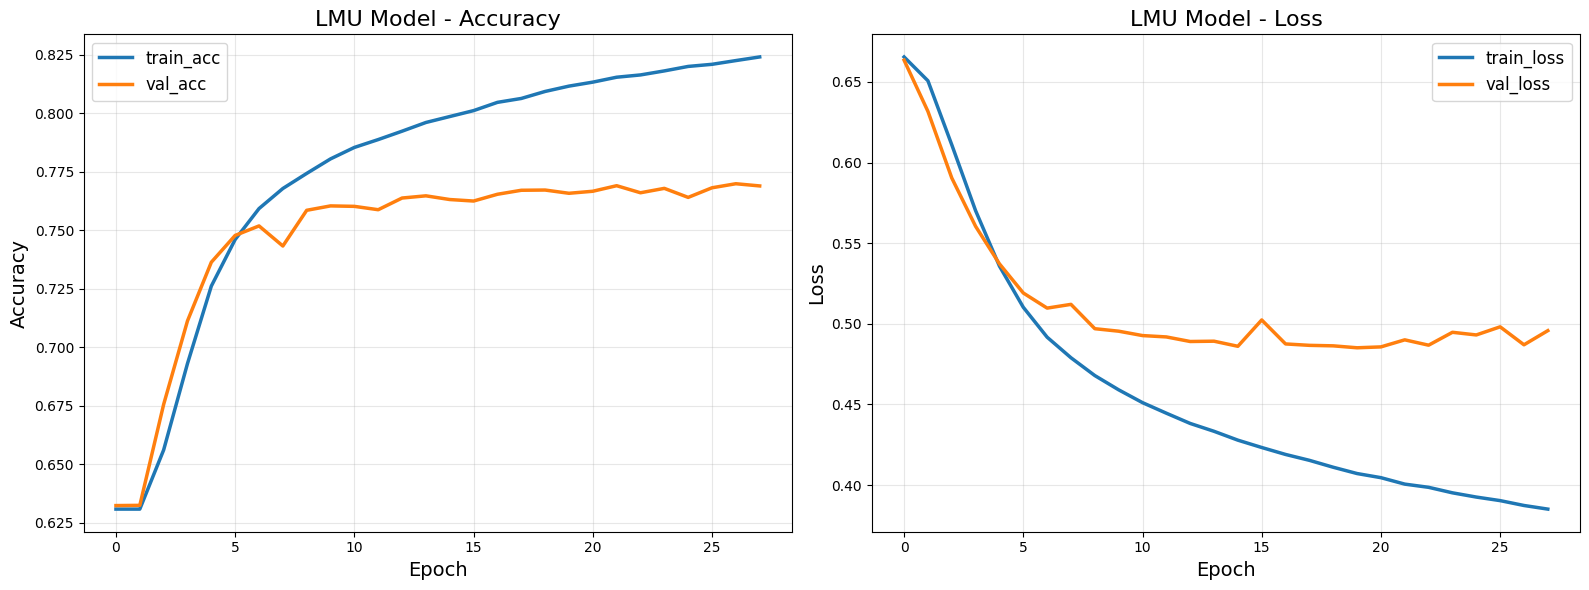

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 50.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 161740
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 21
Val metrics: {'loss': 0.4900646263395618, 'time_s': 10.111459374999868, 'acc': 0.769036725609002}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_lmu_task_frac_50/test_results.json

   Test Accuracy: 0.7742 (77.42%)
   Test Loss: 0.4905

TEST SET RESULTS
Overall accuracy: 0.7742
Num classes: 2

1. ROC Curve...


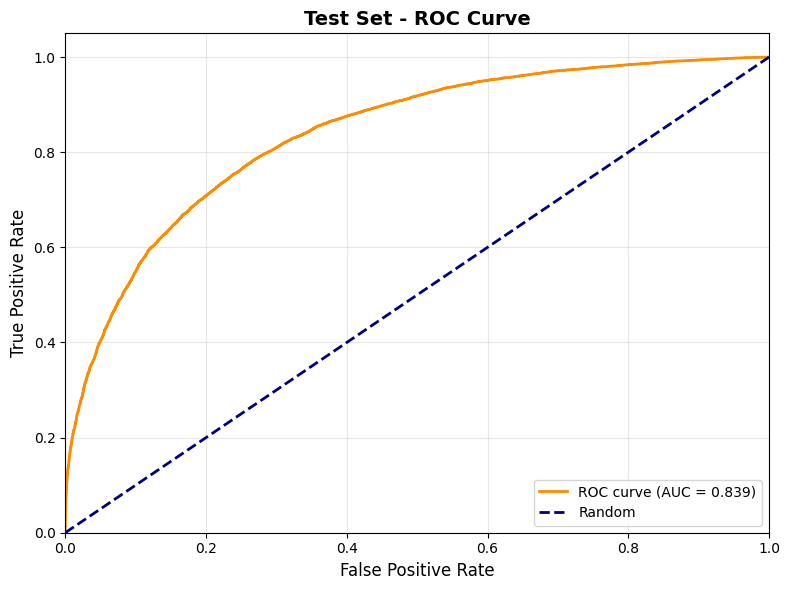

2. Precision-Recall Curve...


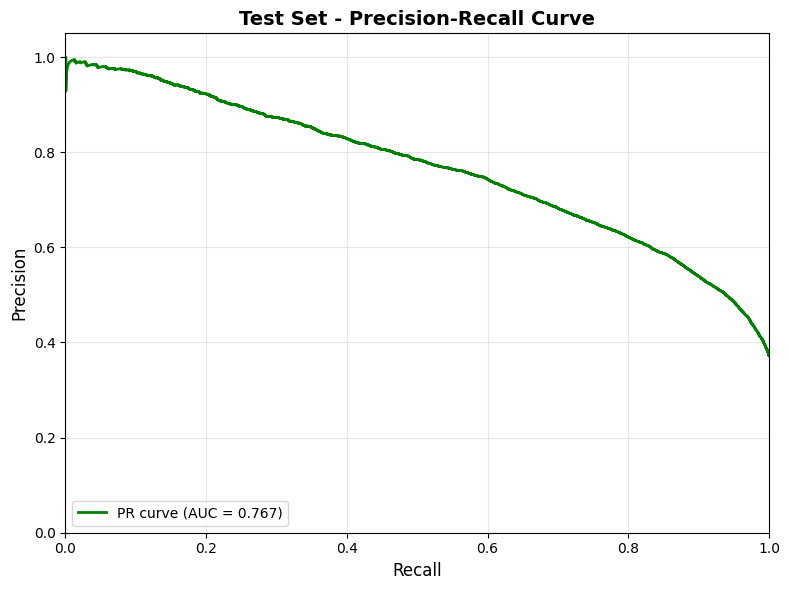

3. Confusion Matrix...


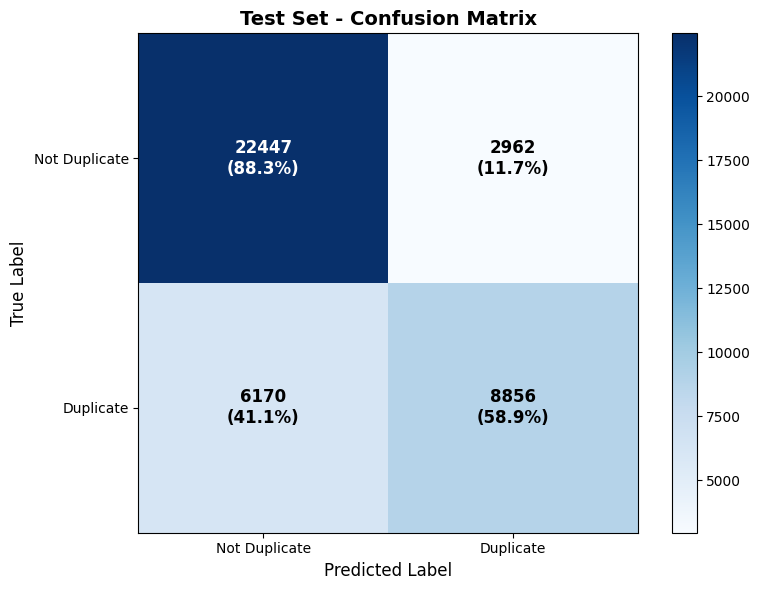

4. Threshold Analysis...


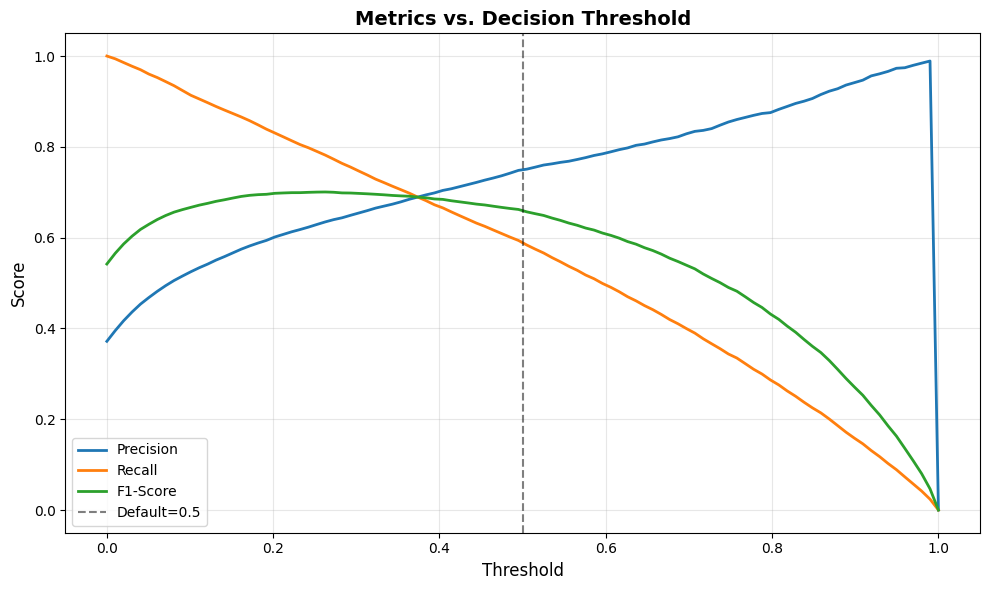

5. Metrics Summary...


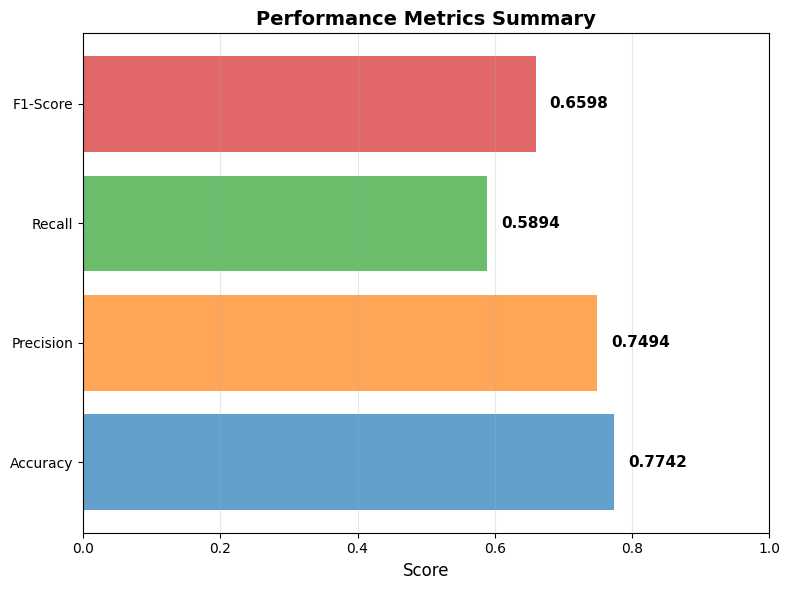

6. Class Distribution...


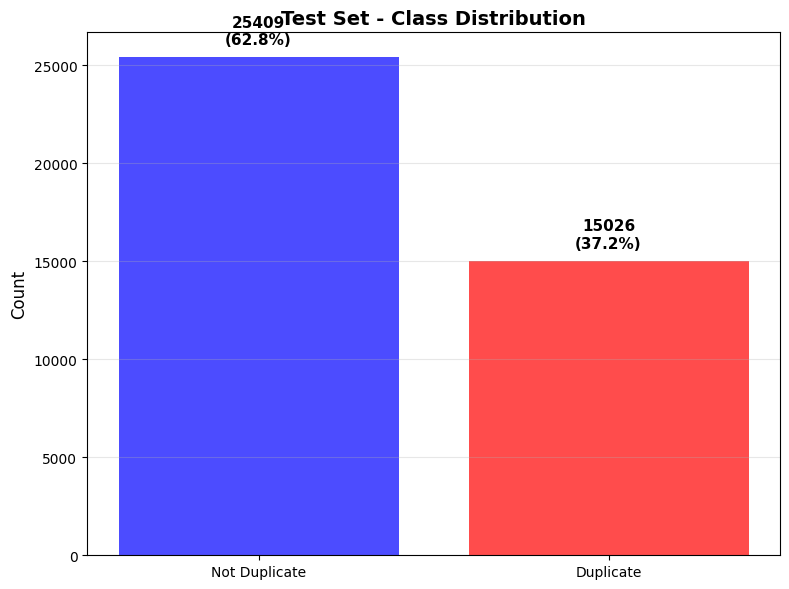


All visualizations generated!


In [7]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/qqp_lmu_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=QQPTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history
    plot_history(history, model_name="LMU")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=QQPTask(),
        best_model_path=best_path,
        num_classes=2,
        use_test_set=True,
    )